#Импорт библиотек

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

#Распаковка датасета

In [ ]:
import zipfile
import os

zip_path = "horses-or-humans.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Датасет распакован")

Датасет распакован


#Определение преобразований и загрузка данных

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # без RandomHorizontalFlip
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_data = datasets.ImageFolder("dataset/horse-or-human/train", transform=train_transform)
val_data   = datasets.ImageFolder("dataset/horse-or-human/validation", transform=val_transform)
test_data  = datasets.ImageFolder("dataset/horse-or-human/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = train_data.classes
print("Классы:", class_names)

Классы: ['horses', 'humans']


#Визуализация данных

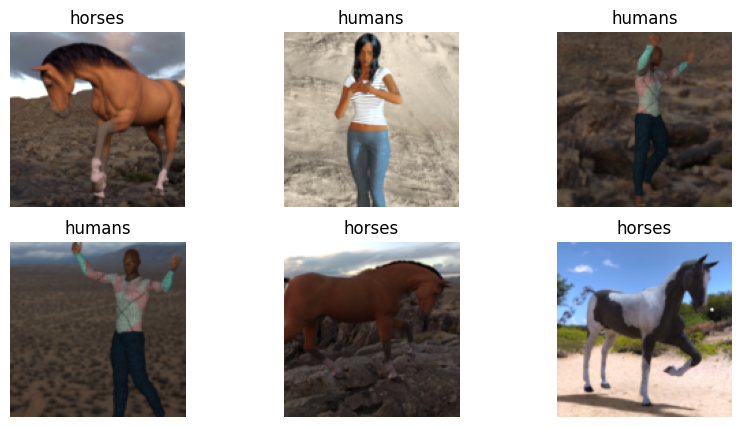

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)

    img = images[i].clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean

    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

#Архитектура нейронной сети

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, dropout_rate=0.7):
        super().__init__()
        # Блоки для извлечения признаков
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 2
            nn.Conv2d(8, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 3
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Классификатор
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), # Адаптивный пулинг вместо фиксированного
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#Инициализации компонентов для обучения

In [ ]:
# Инициализация устройства, модели, лосса и оптимизатора
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN().to(device)

criterion = nn.CrossEntropyLoss()
# Используем оптимизатор Adam с планировщиком скорости обучения
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
# Инициализация списков для отслеживания метрик
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Перемещаем данные на устройство
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Собираем статистику
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Вычисляем метрики для эпохи
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Validation accuracy
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step() # обновляем learning rate!

    current_lr = scheduler.get_last_lr()[0]  # Получаем текущий learning rate
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.6f}")

Epoch 1/10 | Train Loss: 0.6699 | Train Acc: 0.5570 | Val Loss: 0.6624 | Val Acc: 0.8320 | LR: 0.000100
Epoch 2/10 | Train Loss: 0.6070 | Train Acc: 0.6962 | Val Loss: 0.5571 | Val Acc: 0.7812 | LR: 0.000100
Epoch 3/10 | Train Loss: 0.5432 | Train Acc: 0.7653 | Val Loss: 0.4702 | Val Acc: 0.7969 | LR: 0.000100
Epoch 4/10 | Train Loss: 0.4990 | Train Acc: 0.7955 | Val Loss: 0.4202 | Val Acc: 0.8281 | LR: 0.000100
Epoch 5/10 | Train Loss: 0.4608 | Train Acc: 0.8228 | Val Loss: 0.4291 | Val Acc: 0.8164 | LR: 0.000100
Epoch 6/10 | Train Loss: 0.4191 | Train Acc: 0.8569 | Val Loss: 0.4040 | Val Acc: 0.8320 | LR: 0.000100
Epoch 7/10 | Train Loss: 0.3896 | Train Acc: 0.8744 | Val Loss: 0.4300 | Val Acc: 0.8203 | LR: 0.000100
Epoch 8/10 | Train Loss: 0.3513 | Train Acc: 0.8812 | Val Loss: 0.4193 | Val Acc: 0.8320 | LR: 0.000100
Epoch 9/10 | Train Loss: 0.3427 | Train Acc: 0.8802 | Val Loss: 0.4635 | Val Acc: 0.8281 | LR: 0.000100
Epoch 10/10 | Train Loss: 0.2856 | Train Acc: 0.9007 | Val Loss:

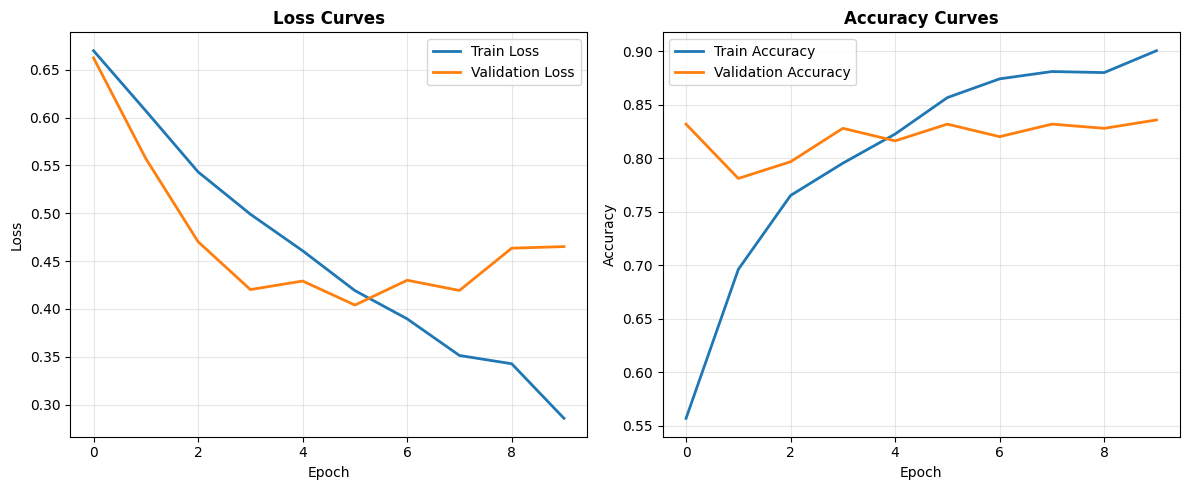

In [ ]:
plt.figure(figsize=(12, 5))

# График 1: Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.title("Loss Curves", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
plt.title("Accuracy Curves", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

      horses       0.73      0.81      0.77        27
      humans       0.78      0.69      0.73        26

    accuracy                           0.75        53
   macro avg       0.76      0.75      0.75        53
weighted avg       0.76      0.75      0.75        53

[[22  5]
 [ 8 18]]
